In [85]:
!pip install ultralytics scikit-learn


In [86]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
from sklearn.cluster import KMeans


In [87]:
model = YOLO("yolov8n.pt")

# YOLOv8 internal PyTorch model
yolo_model = model.model

# Take only backbone layers (feature extractor)
backbone = yolo_model.model[:10]
backbone.eval()


Sequential(
  (0): Conv(
    (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (1): Conv(
    (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
    (act): SiLU(inplace=True)
  )
  (2): C2f(
    (cv1): Conv(
      (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (cv2): Conv(
      (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (m): ModuleList(
      (0): Bottleneck(
        (cv1): Conv(
        

In [89]:
image_path = "Path_with_bike.png"

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Resize for YOLO backbone
image_resized = cv2.resize(image, (640, 640))

# Convert to tensor
x = torch.from_numpy(image_resized).permute(2, 0, 1).unsqueeze(0)
x = x.float() / 255.0


In [90]:
with torch.no_grad():
    features = backbone(x)


In [91]:
feat = features.squeeze(0).permute(1, 2, 0).cpu().numpy()
H, W, C = feat.shape

pixel_features = feat.reshape(-1, C)


In [149]:
K = 5  # number of clusters

kmeans = KMeans(n_clusters=K, random_state=42)
labels = kmeans.fit_predict(pixel_features)


In [150]:
seg_map = labels.reshape(H, W)


In [151]:
np.random.seed(42)
colors = np.random.randint(0, 255, size=(K, 3), dtype=np.uint8)



In [152]:
cluster_color_map = np.zeros((H, W, 3), dtype=np.uint8)

for i in range(K):
    cluster_color_map[seg_map == i] = colors[i]


In [153]:
cluster_color_map = cv2.resize(
    cluster_color_map,
    (image.shape[1], image.shape[0]),
    interpolation=cv2.INTER_NEAREST
)


In [154]:
alpha = 0.5  # transparency

overlay = (image * (1 - alpha) + cluster_color_map * alpha).astype(np.uint8)


(np.float64(-0.5), np.float64(1918.5), np.float64(996.5), np.float64(-0.5))

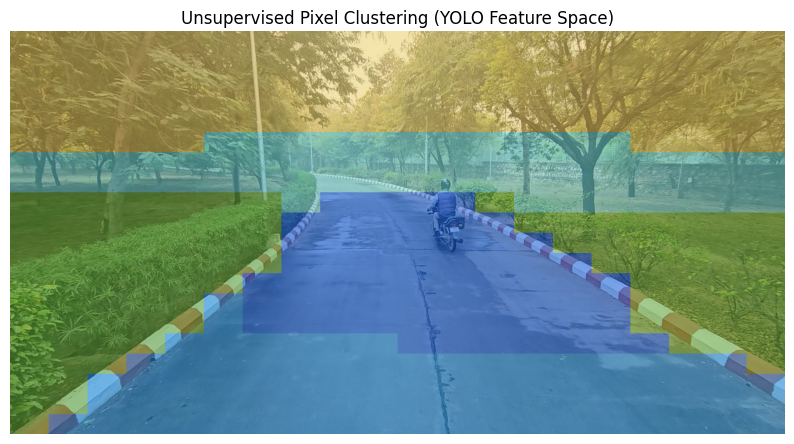

In [155]:
plt.figure(figsize=(10, 6))
plt.imshow(overlay)
plt.title("Unsupervised Pixel Clustering (YOLO Feature Space)")
plt.axis("off")
